# Data Understanding

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 2.1. Data Collection

The analysis utilizes four main datasets:
- **Detailed Reviews**: 6,622 rows × 21 columns
- **Featured Reviews**: 512 rows × 21 columns  
- **Overview**: 96 rows × 22 columns
- **All Data**: 96 rows × 43 columns

**Primary Dataset**: Detailed Reviews (6,622 rows, 21 columns)

In [4]:
# Load dataset utama
df_detailed = pd.read_csv('Assets/data/csv/all-task-3-detailed-reviews.csv')
df_featured = pd.read_csv('Assets/data/csv/all-task-3-featured-reviews.csv')
df_overview = pd.read_csv('Assets/data/csv/all-task-3-overview.csv')
df_all = pd.read_csv('Assets/data/csv/all-task-3.csv')

print(f"Dataset loaded:")
print(f"  - Detailed Reviews: {df_detailed.shape}")
print(f"  - Featured Reviews: {df_featured.shape}")
print(f"  - Overview: {df_overview.shape}")
print(f"  - All Data: {df_all.shape}")

Dataset loaded:
  - Detailed Reviews: (6622, 21)
  - Featured Reviews: (512, 21)
  - Overview: (96, 22)
  - All Data: (96, 43)


In [5]:
df = df_detailed.copy()
print(f"Menggunakan dataset utama: Detailed Reviews ({df.shape[0]} rows, {df.shape[1]} columns)")

Menggunakan dataset utama: Detailed Reviews (6622 rows, 21 columns)


## 2.2. Data Description

### 2.2.1. Basic Information

**Dataset Overview:**
- Total Records: 6,622
- Total Features: 21
- Memory Usage: 9.87 MB

**Data Structure:**
- 17 object type columns
- 3 integer type columns  
- 1 float type column

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6622 entries, 0 to 6621
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   place_id                             6622 non-null   object 
 1   place_name                           6622 non-null   object 
 2   review_id                            6622 non-null   object 
 3   review_link                          6622 non-null   object 
 4   name                                 6622 non-null   object 
 5   reviewer_id                          6622 non-null   object 
 6   reviewer_profile                     6622 non-null   object 
 7   rating                               6622 non-null   int64  
 8   review_text                          3455 non-null   object 
 9   published_at                         6622 non-null   object 
 10  published_at_date                    6622 non-null   object 
 11  response_from_owner_text      

In [7]:
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Total Records: 6,622
Total Features: 21
Memory Usage: 9.87 MB


### 2.2.2. Data Types Overview

The dataset contains a mix of data types:
- **Object columns**: place_id, place_name, review_id, review_link, name, reviewer_id, reviewer_profile, review_text, published_at, published_at_date, response_from_owner_text, response_from_owner_ago, response_from_owner_date, review_translated_text, response_from_owner_translated_text, experience_details, review_photos
- **Integer columns**: rating, total_number_of_reviews_by_reviewer, total_number_of_photos_by_reviewer
- **Float column**: is_local_guide

In [8]:
print(df.dtypes.value_counts())

object     17
int64       3
float64     1
Name: count, dtype: int64


In [9]:
print("Detailed Dtypes:")
print(df.dtypes)

Detailed Dtypes:
place_id                                object
place_name                              object
review_id                               object
review_link                             object
name                                    object
reviewer_id                             object
reviewer_profile                        object
rating                                   int64
review_text                             object
published_at                            object
published_at_date                       object
response_from_owner_text                object
response_from_owner_ago                 object
response_from_owner_date                object
total_number_of_reviews_by_reviewer      int64
total_number_of_photos_by_reviewer       int64
is_local_guide                         float64
review_translated_text                  object
response_from_owner_translated_text     object
experience_details                      object
review_photos                           obj

### 2.2.3. Descriptive Statistics

#### Numerical Columns

| Statistic | Rating | Total Reviews by Reviewer | Total Photos by Reviewer | Is Local Guide |
|-----------|--------|--------------------------|-------------------------|----------------|
| Count | 6,622 | 6,622 | 6,622 | 3,908 |
| Mean | 4.29 | 53.86 | 215.97 | 1.0 |
| Std | 1.15 | 145.73 | 1,873.37 | 0.0 |
| Min | 1 | 0 | 0 | 1.0 |
| 25% | 4 | 2 | 1 | 1.0 |
| 50% | 5 | 9 | 12 | 1.0 |
| 75% | 5 | 44 | 79.75 | 1.0 |
| Max | 5 | 4,707 | 124,756 | 1.0 |

In [10]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(df[numerical_cols].describe())

            rating  total_number_of_reviews_by_reviewer  \
count  6622.000000                          6622.000000   
mean      4.288281                            53.856690   
std       1.153567                           145.731915   
min       1.000000                             0.000000   
25%       4.000000                             2.000000   
50%       5.000000                             9.000000   
75%       5.000000                            44.000000   
max       5.000000                          4707.000000   

       total_number_of_photos_by_reviewer  is_local_guide  
count                         6622.000000          3908.0  
mean                           215.968137             1.0  
std                           1873.372229             0.0  
min                              0.000000             1.0  
25%                              1.000000             1.0  
50%                             12.000000             1.0  
75%                             79.750000       

#### Categorical Columns

Key categorical features show:
- **place_id**: 95 unique values, 0% missing
- **place_name**: 94 unique values, 0% missing  
- **review_id**: 6,622 unique values, 0% missing
- **review_link**: 6,622 unique values, 0% missing
- **name**: 6,133 unique values, 0% missing

In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols[:5]:  # Limit to first 5 untuk menghindari output terlalu panjang
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Top value: {df[col].mode().iloc[0] if not df[col].mode().empty else 'N/A'}")
    print(f"  Missing values: {df[col].isnull().sum()} ({df[col].isnull().mean()*100:.1f}%)")


place_id:
  Unique values: 95
  Top value: ChIJ-ZhJ6VEG2C0RUbuouwLtOMk
  Missing values: 0 (0.0%)

place_name:
  Unique values: 94
  Top value: Pantai Slopeng
  Missing values: 0 (0.0%)

review_id:
  Unique values: 6622
  Top value: ChRDSUhNMG9nS0VJQ0FnSUMxM09BSBAB
  Missing values: 0 (0.0%)

review_link:
  Unique values: 6622
  Top value: https://www.google.com/maps/reviews/data=!4m8!14m7!1m6!2m5!1sChRDSUhNMG9nS0VJQ0FnSUMxM09BSBAB!2m1!1s0x0:0x8550176773c06614!3m1!1s2@1:CIHM0ogKEICAgIC13OAH%7CCgwIiKakrAYQqNnLzgI%7C?hl=en
  Missing values: 0 (0.0%)

name:
  Unique values: 6133
  Top value: Don Jimmy
  Missing values: 0 (0.0%)


## 2.3. Data Exploration

### 2.3.1. Rating Distribution

**Rating Statistics:**
- Mean: 4.29
- Median: 5.00
- Mode: 5
- Standard Deviation: 1.15

The rating distribution shows a strong positive bias with most reviews being 4 or 5 stars, indicating generally positive user experiences.

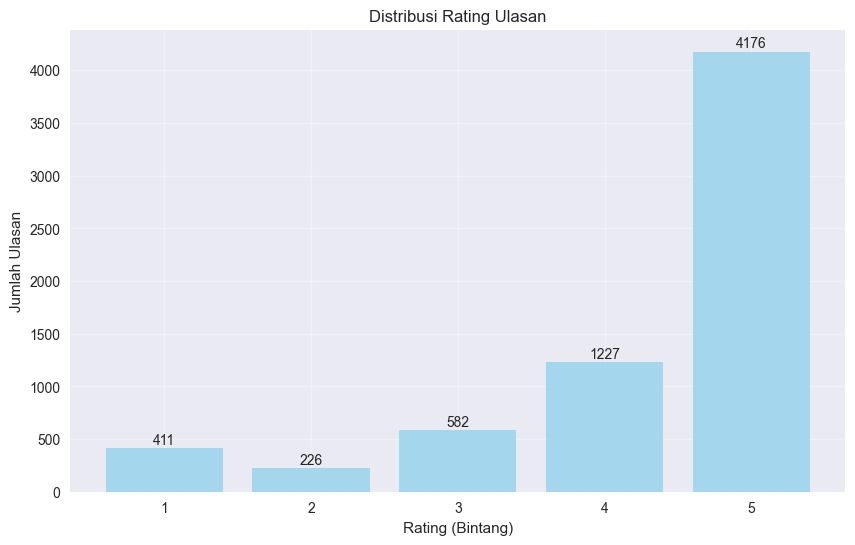

In [12]:
plt.figure(figsize=(10, 6))
rating_counts = df['rating'].value_counts().sort_index()
plt.bar(rating_counts.index, rating_counts.values, color='skyblue', alpha=0.7)
plt.xlabel('Rating (Bintang)')
plt.ylabel('Jumlah Ulasan')
plt.title('Distribusi Rating Ulasan')
for i, v in enumerate(rating_counts.values):
    plt.text(rating_counts.index[i], v + 10, str(v), ha='center', va='bottom')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
print(f"Rating Statistics:")
print(f"  Mean: {df['rating'].mean():.2f}")
print(f"  Median: {df['rating'].median():.2f}")
print(f"  Mode: {df['rating'].mode().iloc[0] if not df['rating'].mode().empty else 'N/A'}")
print(f"  Std Dev: {df['rating'].std():.2f}")

Rating Statistics:
  Mean: 4.29
  Median: 5.00
  Mode: 5
  Std Dev: 1.15


### 2.3.2. Missing Values Analysis

The dataset shows significant missing values in several columns:
- **response_from_owner_text**: 99.4% missing
- **response_from_owner_ago**: 99.4% missing  
- **response_from_owner_date**: 99.4% missing
- **review_translated_text**: 52.0% missing
- **review_text**: 47.8% missing
- **is_local_guide**: 41.0% missing

This indicates that owner responses are rare and many reviews lack translated text.

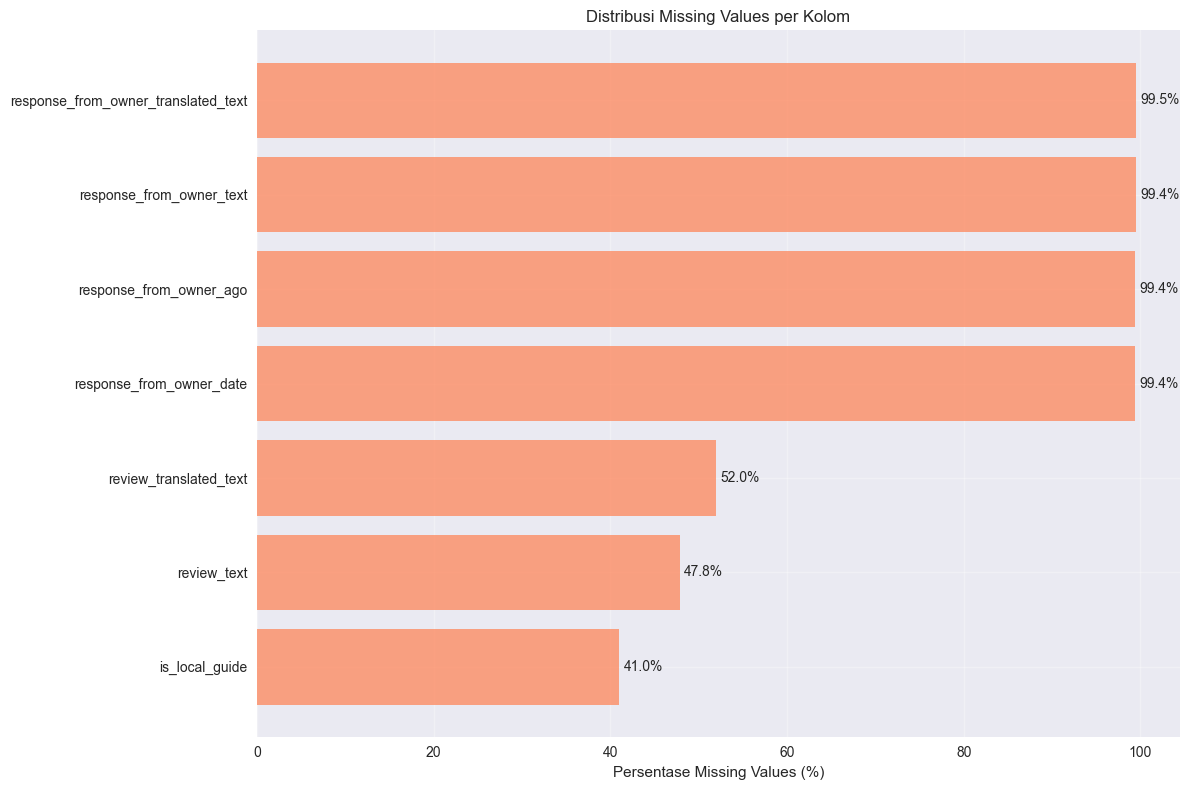

In [14]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

plt.figure(figsize=(12, 8))
missing_df = pd.DataFrame({'column': missing_data.index, 'missing_count': missing_data.values, 'missing_percent': missing_percent.values})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_percent', ascending=False)

plt.barh(missing_df['column'], missing_df['missing_percent'], color='coral', alpha=0.7)
plt.xlabel('Persentase Missing Values (%)')
plt.title('Distribusi Missing Values per Kolom')
plt.gca().invert_yaxis()
for i, v in enumerate(missing_df['missing_percent']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3.3. Text Length Review Distribution

The analysis examines the distribution of review text lengths, which provides insights into the depth and detail of user reviews. This metric helps understand user engagement and review quality patterns across different ratings and reviewer types.

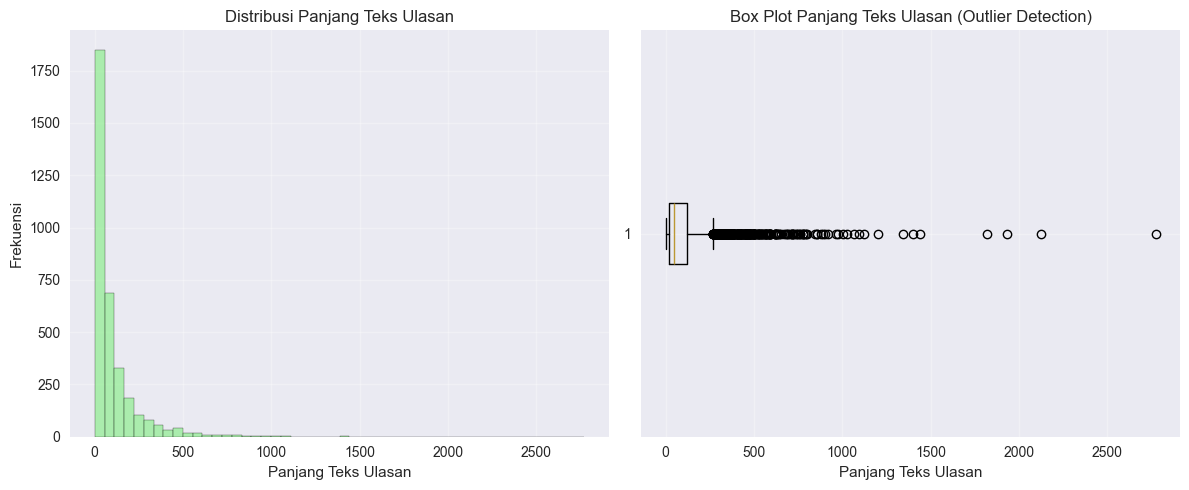

In [15]:
df['review_length'] = df['review_text'].str.len()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['review_length'].dropna(), bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
plt.xlabel('Panjang Teks Ulasan')
plt.ylabel('Frekuensi')
plt.title('Distribusi Panjang Teks Ulasan')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Box plot untuk detect outlier panjang teks
plt.boxplot(df['review_length'].dropna(), vert=False)
plt.xlabel('Panjang Teks Ulasan')
plt.title('Box Plot Panjang Teks Ulasan (Outlier Detection)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
print(f"Review Length Statistics:")
print(f"  Mean: {df['review_length'].mean():.1f} characters")
print(f"  Median: {df['review_length'].median():.1f} characters")
print(f"  Min: {df['review_length'].min():.1f} characters")
print(f"  Max: {df['review_length'].max():.1f} characters")
print(f"  Std Dev: {df['review_length'].std():.1f} characters")

Review Length Statistics:
  Mean: 101.8 characters
  Median: 49.0 characters
  Min: 1.0 characters
  Max: 2772.0 characters
  Std Dev: 157.0 characters


### 2.3.4. Correlation between Numerical Variables

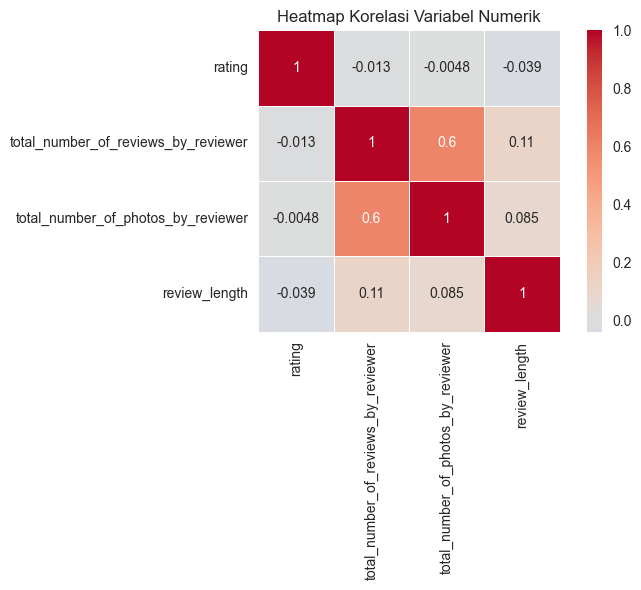

In [17]:
numerical_for_corr = df[['rating', 'total_number_of_reviews_by_reviewer', 
                        'total_number_of_photos_by_reviewer', 'review_length']].copy()

plt.figure(figsize=(8, 6))
correlation_matrix = numerical_for_corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

## 2.4. Data Quality

### 2.4.1. Missing Values Analysis

In [18]:
high_missing = missing_df[missing_df['missing_percent'] > 50]
for _, row in high_missing.iterrows():
    print(f"  - {row['column']}: {row['missing_count']} ({row['missing_percent']:.1f}%)")

  - response_from_owner_translated_text: 6589 (99.5%)
  - response_from_owner_text: 6585 (99.4%)
  - response_from_owner_ago: 6583 (99.4%)
  - response_from_owner_date: 6583 (99.4%)
  - review_translated_text: 3441 (52.0%)


### 2.4.2. Duplicate Analysis

In [19]:
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate review_id: {df['review_id'].duplicated().sum()}")

Total duplicate rows: 0
Duplicate review_id: 0


### 2.4.3. Outlier Detection for Numerical Variables

In [20]:
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

numerical_outliers = {}
for col in numerical_cols:
    outliers = detect_outliers_iqr(df[col].dropna())
    numerical_outliers[col] = len(outliers)
    print(f"  - {col}: {len(outliers)} outliers ({len(outliers)/len(df[col].dropna())*100:.1f}%)")

  - rating: 637 outliers (9.6%)
  - total_number_of_reviews_by_reviewer: 837 outliers (12.6%)
  - total_number_of_photos_by_reviewer: 942 outliers (14.2%)
  - is_local_guide: 0 outliers (0.0%)


### 2.4.4. Data Consistency Check

In [21]:
print("Rating value consistency:")
print(f"  Valid ratings (1-5): {df['rating'].between(1, 5).all()}")
print(f"  Invalid ratings: {len(df[~df['rating'].between(1, 5)])}")

Rating value consistency:
  Valid ratings (1-5): True
  Invalid ratings: 0


### 2.4.5. Review Text Quality Analysis

In [22]:
review_text_stats = df['review_text'].dropna()
short_reviews = review_text_stats[review_text_stats.str.len() < 10]
print(f"  Total reviews with text: {len(review_text_stats)}")
print(f"  Very short reviews (<10 chars): {len(short_reviews)} ({len(short_reviews)/len(review_text_stats)*100:.1f}%)")
print(f"  Sample short reviews:")
for i, review in enumerate(short_reviews.head(5)):
    print(f"    {i+1}. '{review}'")

  Total reviews with text: 3455
  Very short reviews (<10 chars): 414 (12.0%)
  Sample short reviews:
    1. 'Istimewa'
    2. 'Yuuuhuuuu'
    3. 'Asik coyy'
    4. 'Mantap'
    5. 'Cukup'


## Summary

In [23]:
total_records = len(df)
records_with_review_text = df['review_text'].notna().sum()

print(f"DATA QUANTITY:")
print(f"  • Total records: {total_records:,}")
print(f"  • Records with review text: {records_with_review_text:,} ({records_with_review_text/total_records*100:.1f}%)")
print(f"  • Records without review text: {total_records - records_with_review_text:,} ({(total_records - records_with_review_text)/total_records*100:.1f}%)")

print(f"\nDATA QUALITY ISSUES IDENTIFIED:")
issues = []

# Check for critical issues
if df['review_text'].isna().mean() > 0.3:
    issues.append(f"  • High missing review text ({df['review_text'].isna().mean()*100:.1f}%)")

if df.duplicated().sum() > 0:
    issues.append(f"  • {df.duplicated().sum()} duplicate rows found")

if any(count > 100 for count in numerical_outliers.values()):
    issues.append("  • Significant outliers in numerical variables")

if len(short_reviews) > 100:
    issues.append(f"  • {len(short_reviews)} very short reviews (<10 chars)")

if issues:
    for issue in issues:
        print(issue)
else:
    print("  • No critical data quality issues identified")

DATA QUANTITY:
  • Total records: 6,622
  • Records with review text: 3,455 (52.2%)
  • Records without review text: 3,167 (47.8%)

DATA QUALITY ISSUES IDENTIFIED:
  • High missing review text (47.8%)
  • Significant outliers in numerical variables
  • 414 very short reviews (<10 chars)
